# Design2Code Model Setup and Testing
## Qwen3-VL vs VLM_WebSight_finetuned

This notebook sets up both models and tests them on Design2Code tasks.

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: Tesla T4


In [1]:
!nvidia-smi

Thu Nov  6 22:11:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Run this once to install all dependencies
!pip install accelerate
!pip install torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers accelerate sentencepiece pillow
!pip install qwen-vl-utils  # Qwen specific utilities
!pip install -U datasets huggingface_hub

In [ ]:
! pip install transformers -U

  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.1.1
    Uninstalling huggingface_hub-1.1.1:
      Successfully uninstalled huggingface_hub-1.1.1


In [ ]:
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoProcessor, AutoModelForVision2Seq
from transformers import Qwen3VLForConditionalGeneration, AutoTokenizer
from qwen_vl_utils import process_vision_info

## Setup Qwen3-VL Model

In [ ]:
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-2B-Instruct", dtype="auto", device_map="auto"
)

qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-2B-Instruct")

print("Qwen3-VL loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Qwen3-VL loaded successfully!


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Model device:", next(qwen_model.parameters()).device)

CUDA available: True
Model device: cuda:0


In [ ]:
!nvidia-smi

Thu Nov  6 06:32:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             28W /   70W |    4180MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Test Qwen3-VL

In [ ]:
from datasets import load_dataset
ds = load_dataset("SALT-NLP/Design2Code-hf", split="train")
sample = ds[0]   # pick the first item
print(sample.keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dict_keys(['image', 'text'])


In [ ]:
!nvidia-smi

Thu Nov  6 06:56:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             29W /   70W |    5058MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

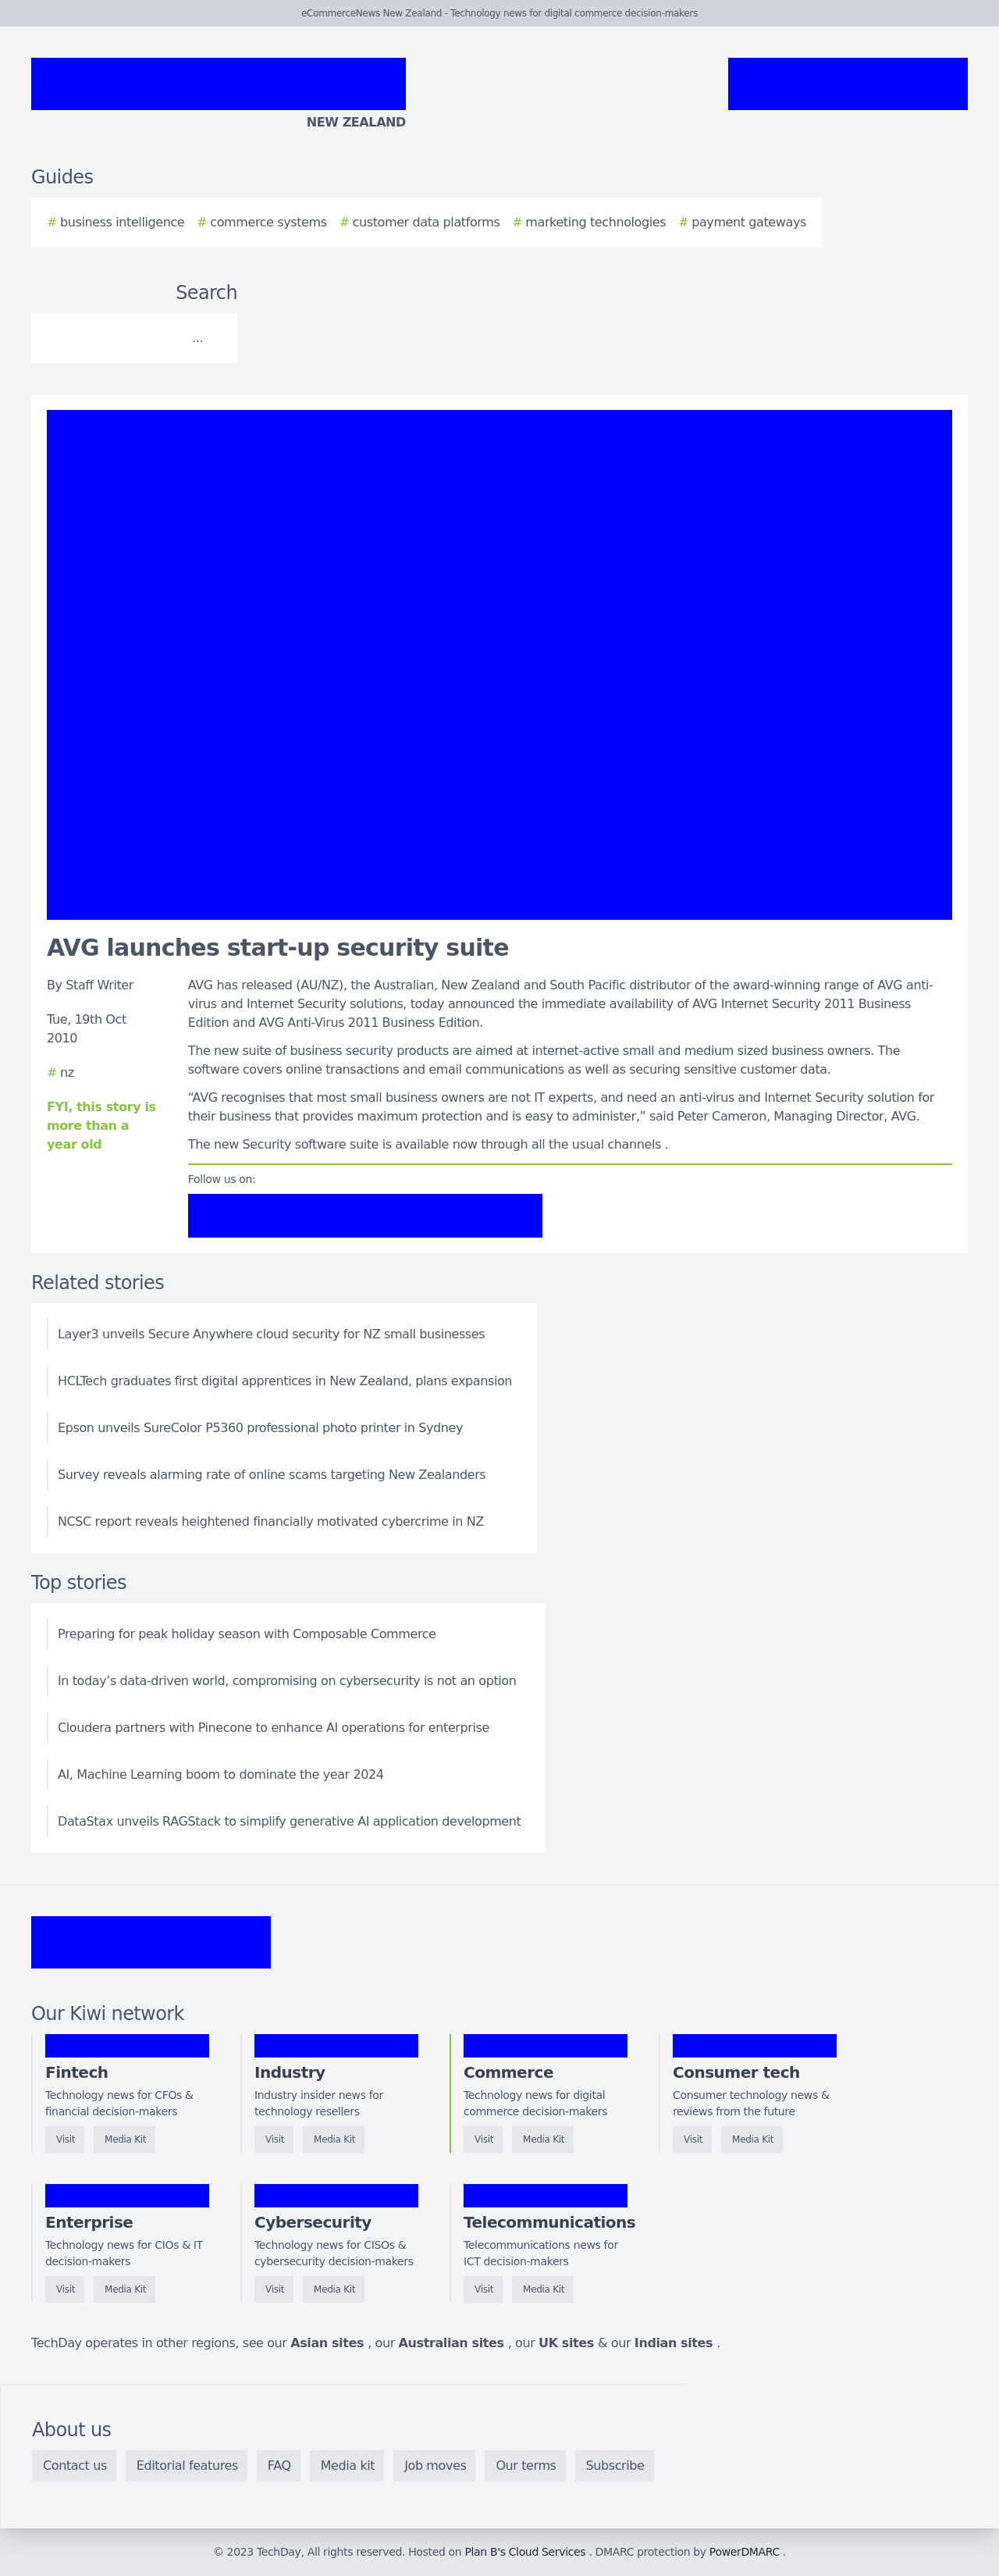

In [ ]:
image

In [ ]:
image = sample["image"]

# Save the image temporarily if your function expects a path
image_path = "sample.png"
image.save(image_path)

# Run your code generator
# generated_code = generate_code_qwen(image_path = image_path)
# print(generated_code[:500])

In [ ]:
def generate_code_qwen(image_path, prompt="Convert this UI design into complete HTML and CSS code."):
    """
    Generate HTML/CSS code using Qwen3-VL-2B-Instruct

    Args:
        image_path: Path to image file or URL
        prompt: Instruction prompt for code generation

    Returns:
        Generated HTML/CSS code as string
    """
    # Load image
    if image_path.startswith('http'):
        response = requests.get(image_path)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_path).convert("RGB")

    # Prepare conversation in Qwen format
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    # Apply chat template
    text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Process vision inputs
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(qwen_model.device)

    # Generate
    with torch.no_grad():
        output_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=2048,
            temperature=0.7,
            do_sample=True
        )

    # Decode
    generated_text = qwen_processor.batch_decode(
        output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )[0]

    return generated_text


# Use a web design screenshot for testing
test_image = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"

qwen_output = generate_code_qwen(test_image)
print("\n=== Qwen3-VL-2B Test Output ===")
print(qwen_output[:1000])  # Print first 1000 chars
print("\n... (output truncated)")
print(f"\nTotal output length: {len(qwen_output)} characters")


=== Qwen3-VL-2B Test Output ===
user
Convert this UI design into complete HTML and CSS code.
assistant
```html
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Classic Car</title>
  <style>
    body {
      margin: 0;
      padding: 0;
      font-family: 'Arial', sans-serif;
      background-color: #f5f5f5;
      display: flex;
      flex-direction: column;
      align-items: center;
      justify-content: center;
      min-height: 100vh;
      color: #333;
    }

   .container {
      width: 100%;
      max-width: 800px;
      padding: 20px;
      background-color: white;
      border-radius: 10px;
      box-shadow: 0 0 10px rgba(0,0,0,0.1);
      text-align: center;
      margin: 0 auto;
    }

    h1 {
      color: #0066cc;
      margin-bottom: 20px;
      font-size: 2.5em;
    }

   .car {
      width: 100%;
      max-width: 90%;
      margin: 20px auto;
      background-color: #000;


##  Setup VLM_WebSight_finetuned Model

In [ ]:
import sys, types, torch, requests
from transformers import AutoModelForCausalLM, AutoProcessor

# --- load model & processor ---
websight_processor = AutoProcessor.from_pretrained(
    "HuggingFaceM4/VLM_WebSight_finetuned"
)

websight_model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceM4/VLM_WebSight_finetuned",
    trust_remote_code=True,
    torch_dtype="auto",        # lets HF pick fp16/bf16
    device_map="auto",         # loads directly onto GPU if space allows
    low_cpu_mem_usage=True
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Test VLM_WebSight_finetuned

In [ ]:
!pip install flash_attn

In [2]:
import torch

from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor

from transformers.image_utils import to_numpy_array, PILImageResampling, ChannelDimension
from transformers.image_transforms import resize, to_channel_dimension_format

DEVICE = torch.device("cuda")
PROCESSOR = AutoProcessor.from_pretrained(
    "HuggingFaceM4/VLM_WebSight_finetuned",
)
MODEL = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceM4/VLM_WebSight_finetuned",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
).to(DEVICE)
image_seq_len = MODEL.config.perceiver_config.resampler_n_latents
BOS_TOKEN = PROCESSOR.tokenizer.bos_token
BAD_WORDS_IDS = PROCESSOR.tokenizer(["<image>", "<fake_token_around_image>"], add_special_tokens=False).input_ids


def convert_to_rgb(image):
    # `image.convert("RGB")` would only work for .jpg images, as it creates a wrong background
    # for transparent images. The call to `alpha_composite` handles this case
    if image.mode == "RGB":
        return image

    image_rgba = image.convert("RGBA")
    background = Image.new("RGBA", image_rgba.size, (255, 255, 255))
    alpha_composite = Image.alpha_composite(background, image_rgba)
    alpha_composite = alpha_composite.convert("RGB")
    return alpha_composite

# The processor is the same as the Idefics processor except for the BILINEAR interpolation,
# so this is a hack in order to redefine ONLY the transform method
def custom_transform(x):
    x = convert_to_rgb(x)
    x = to_numpy_array(x)
    x = resize(x, (960, 960), resample=PILImageResampling.BILINEAR)
    x = PROCESSOR.image_processor.rescale(x, scale=1 / 255)
    x = PROCESSOR.image_processor.normalize(
        x,
        mean=PROCESSOR.image_processor.image_mean,
        std=PROCESSOR.image_processor.image_std
    )
    x = to_channel_dimension_format(x, ChannelDimension.FIRST)
    x = torch.tensor(x)
    return x

inputs = PROCESSOR.tokenizer(
    f"{BOS_TOKEN}<fake_token_around_image>{'<image>' * image_seq_len}<fake_token_around_image>",
    return_tensors="pt",
    add_special_tokens=False,
)
inputs["pixel_values"] = PROCESSOR.image_processor([image], transform=custom_transform)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
generated_ids = MODEL.generate(**inputs, bad_words_ids=BAD_WORDS_IDS, max_length=4096)
generated_text = PROCESSOR.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(generated_text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.69G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 6.12 MiB is free. Process 3206 has 14.73 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 264.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch
from PIL import Image
from transformers.image_utils import to_numpy_array, PILImageResampling, ChannelDimension
from transformers.image_transforms import resize, to_channel_dimension_format
import requests

def convert_to_rgb(image):
    """Convert image to RGB, handling transparency properly"""
    if image.mode == "RGB":
        return image

    image_rgba = image.convert("RGBA")
    background = Image.new("RGBA", image_rgba.size, (255, 255, 255))
    alpha_composite = Image.alpha_composite(background, image_rgba)
    alpha_composite = alpha_composite.convert("RGB")
    return alpha_composite


def custom_transform(x):
    """
    Custom image transformation for WebSight model
    - Converts to RGB
    - Resizes to 960x960 with BILINEAR interpolation
    - Normalizes with model-specific mean/std
    """
    x = convert_to_rgb(x)
    x = to_numpy_array(x)
    x = resize(x, (960, 960), resample=PILImageResampling.BILINEAR)
    x = websight_processor.image_processor.rescale(x, scale=1 / 255)
    x = websight_processor.image_processor.normalize(
        x,
        mean=websight_processor.image_processor.image_mean,
        std=websight_processor.image_processor.image_std
    )
    x = to_channel_dimension_format(x, ChannelDimension.FIRST)
    x = torch.tensor(x)
    return x


def generate_code_websight(image_path, prompt="Convert this UI design into HTML/CSS.", max_length=512):
    DEVICE = next(websight_model.parameters()).device
    image_seq_len = websight_model.config.perceiver_config.resampler_n_latents
    BOS = websight_processor.tokenizer.bos_token
    bad_ids = websight_processor.tokenizer(["<image>", "<fake_token_around_image>"],
                                           add_special_tokens=False).input_ids

    # Load image
    if image_path.startswith('http'):
        img = Image.open(requests.get(image_path, stream=True).raw)
    else:
        img = Image.open(image_path)
    img = convert_to_rgb(img)

    # Transform
    pixel_values = custom_transform(img).unsqueeze(0).to(DEVICE)

    # Text input
    inputs = websight_processor.tokenizer(
        f"{BOS}<fake_token_around_image>{'<image>' * image_seq_len}<fake_token_around_image>",
        return_tensors="pt",
        add_special_tokens=False
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    inputs["pixel_values"] = pixel_values

    # Generate
    with torch.no_grad():
        ids = websight_model.generate(
            **inputs,
            bad_words_ids=bad_ids,
            max_length=max_length,
            use_cache=False  # ✅ prevents AttributeError
        )

    return websight_processor.batch_decode(ids, skip_special_tokens=True)[0]

# Skip FlashAttention adjustment (not applicable for WebSight)
print("Testing VLM_WebSight_finetuned...")
print("-" * 80)

test_image = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
websight_output = generate_code_websight(test_image)

print("\n=== WebSight Output ===")
print(websight_output[:1000])  # Print first 1000 chars
print("\n... (output truncated)")
print(f"\nTotal output length: {len(websight_output)} characters")

Testing VLM_WebSight_finetuned...
--------------------------------------------------------------------------------


NameError: name 'flash_attn_func' is not defined

In [ ]:
print("Testing VLM_WebSight_finetuned...")
print("-" * 80)

websight_output = generate_code_websight(test_image)
print("\n=== WebSight Output ===")
print(websight_output[:1000])
print("\n... (output truncated)")
print(f"\nTotal output length: {len(websight_output)} characters")

Testing VLM_WebSight_finetuned...
--------------------------------------------------------------------------------


NameError: name 'flash_attn_func' is not defined